# Weekdays Geometry

The LLM research prcess can often be described by the following form:
The causalab codebase starts with an overall objective. The objective is broken up into individual research questions. To find an answer for a research question, we try multiple menthods.
In this notebook, We analyze the geometry of weekdays in middle layer embedding space and compare geodesic "on-manifold" steering (Mon -> Tue -> Wed -> Thu) against linear steering (Mon -> Thu).

Research objective: 
> Comparing geodesic steering against linear steering.

Research questions (RQs):
- **Task performance:** Can the model reliably solve the weekday arithmetic task at all?
- **Layer localization:** At which layer and token position is the causal signal mediated?
- **Subspace localization:** What's the lowest-dimensional subspace mediating most task-related variance?
- **Manifold localization:** Can we identify a one-dimensional manifold that mediates weekdays?
- **Steering evaluation:** How does geometric vs linear steering affect output behavior?

Our task is to select suitable interpretability methods to answer each RQ. Each RQ is an analysis that employs interpretability tools.
We build that analysis in a modular way to quickly iterate on hyperparameters defined in a config. 

## Task performance

First we set up the task and measure whether the model reliably solves it at all. 
The causal model notebook [[link]] demonstrates how to set up tasks.
Here we've already set up the weekday arithmetic task, where the model has to retrieve the day X days after the target day.
The task has been set up with a bunch of default configs. The runner config 

In [1]:
# Define the baseline config, save and load for printing

# # Natural domains arithmetic weekdays task with llama31_8b

# Convention: the defaults list is the source of truth for analysis steps.
# Each `- analysis/<step>` entry mounts that analysis at `cfg.<step>` (via
# `# @package <step>` in the analysis YAML). Add a top-level `<step>:` block
# only when you need to override fields.

baseline_config_yaml = """\
# @package _global_
defaults:
  - /base
  - /task: natural_domains_arithmetic_weekdays
  - /model: llama31_8b # llama32_1b_instruct cannot solve this task
  - /analysis/baseline
  - _self_
task:
  enumerate_all: true # Enumerate all examples in the training set, test = train
  target_variable: result

baseline:
  visualization:
    figure_format: png
"""


from omegaconf import OmegaConf
from causalab.io.configs import save_runner_config, load_runner_config

# Save the config overrides
path = save_runner_config(baseline_config_yaml, 'weekdays_baseline_demo')
print(f'Written to {path}\n')

# Load the full hydra config
cfg = load_runner_config('weekdays_baseline_demo')
print(f'Full hydra config:\n')
print(OmegaConf.to_yaml(cfg))

Written to /mnt/home/can.rager/causalab/causalab/configs/runners/demos/weekdays_baseline_demo.yaml

Full hydra config:

seed: 42
experiment_root: artifacts/natural_domains_arithmetic/llama31_8b/weekdays
slurm:
  time: 04:00:00
task:
  name: natural_domains_arithmetic
  domain_type: weekdays
  variant: weekdays
  number_range: null
  number_groups: null
  max_new_tokens: 1
  colormap: rainbow
  colormap2: null
  intervention_metric: kl
  reference_source: empirical
  n_train: 1000
  n_test: 50
  enumerate_all: true
  balanced: false
  resample_variable: all
  distance_function: hellinger
  isometry:
    distance_function: ${task.distance_function}
    grid_range:
    - 0
    - 7
    grid_resolution: 150
    bin_positions: null
  target_variable: result
model:
  id: llama31_8b
  name: meta-llama/Llama-3.1-8B
  device: auto
  dtype: bfloat16
  slurm:
    gpus: 1
baseline:
  _name_: baseline
  batch_size: 32
  visualization:
    figure_format: png



In [2]:
# Run the eval with the model

# Change the path to the project root
import os
import causalab
import subprocess

project_root = os.path.dirname(os.path.dirname(causalab.__file__))

# Running the `scripts/run_exp.sh baseline_demo` bash command from within this notebook
rc = subprocess.run(
    ["bash", "scripts/run_exp.sh", "weekdays_baseline_demo"],
    cwd=project_root,
)

if rc.returncode == 0:
    print("\n\nBaseline analysis ran successfully!")

[2026-05-05 16:17:19,893][__main__][INFO] - === Step: baseline (baseline) ===
[2026-05-05 16:17:33,269][__main__][INFO] - Running analysis: baseline | target_variable: result
[2026-05-05 16:17:33,271][__main__][INFO] - Resolved config:
seed: 42
experiment_root: artifacts/natural_domains_arithmetic/llama31_8b/weekdays
slurm:
  time: 04:00:00
task:
  name: natural_domains_arithmetic
  domain_type: weekdays
  variant: weekdays
  number_range: null
  number_groups: null
  max_new_tokens: 1
  colormap: rainbow
  colormap2: null
  intervention_metric: kl
  reference_source: empirical
  n_train: 1000
  n_test: 50
  enumerate_all: true
  balanced: false
  resample_variable: all
  distance_function: hellinger
  isometry:
    distance_function: ${task.distance_function}
    grid_range:
    - 0
    - 7
    grid_resolution: 150
    bin_positions: null
  target_variable: result
model:
  id: llama31_8b
  name: meta-llama/Llama-3.1-8B
  device: auto
  dtype: bfloat16
  slurm:
    gpus: 1
baseline:
  

Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00, 145.42it/s]


[2026-05-05 16:17:37,787][causalab.methods.metric][INFO] - Base model accuracy: 45/49 (91.8%)
[2026-05-05 16:17:37,787][causalab.methods.metric][INFO] - Base model prob accuracy: 56.9%
[2026-05-05 16:17:37,793][causalab.analyses.baseline.main][INFO] - Base accuracy: 91.8%
[2026-05-05 16:17:38,084][causalab.analyses.baseline.main][INFO] - Collected per-example logits: 49 examples, 1 steps each
[2026-05-05 16:17:38,157][causalab.analyses.baseline.main][INFO] - Saved full output distributions: torch.Size([49, 128256])
[2026-05-05 16:17:38,178][causalab.analyses.baseline.main][INFO] - Saved decoded top-10 logits for 49 examples.
[2026-05-05 16:17:38,193][causalab.analyses.baseline.main][INFO] - Saved per-class output distributions: torch.Size([7, 7])
Saved figure to artifacts/natural_domains_arithmetic/llama31_8b/weekdays/baseline/ground_truth_dim0.png
[2026-05-05 16:17:38,981][causalab.analyses.path_steering.path_visualization][INFO] - Saved ground truth line plot: artifacts/natural_domai

In [3]:
import json
import os

artifact_dir = os.path.join(project_root, cfg.experiment_root, 'baseline')
print(f'Artifact directory: {artifact_dir}\n')
print('Contents:', sorted(os.listdir(artifact_dir)))

Artifact directory: /mnt/home/can.rager/causalab/artifacts/natural_domains_arithmetic/llama31_8b/weekdays/baseline

Contents: ['accuracy.json', 'confusion_heatmap.png', 'full_output_dists.safetensors', 'ground_truth_dim0.png', 'metadata.json', 'per_class_output_dists.safetensors', 'test_samples.json', 'top_logits.json', 'train_samples.json']


In [4]:
# Show task samples 

with open(os.path.join(artifact_dir, 'train_samples.json')) as f:
    train_samples = json.load(f)['samples']
print(json.dumps(train_samples[:3], indent=2))

[
  {
    "raw_input": "Q: What day is one days after Monday?\nA:",
    "raw_output": " Tuesday"
  },
  {
    "raw_input": "Q: What day is two days after Monday?\nA:",
    "raw_output": " Wednesday"
  },
  {
    "raw_input": "Q: What day is three days after Monday?\nA:",
    "raw_output": " Thursday"
  }
]


In [5]:
# Show task accuracy

with open(os.path.join(artifact_dir, 'accuracy.json')) as f:
    print(json.dumps(json.load(f), indent=2))

{
  "accuracy": 0.9183673469387755,
  "correct": 45,
  "total": 49,
  "prob_accuracy": 0.5688482540450535
}


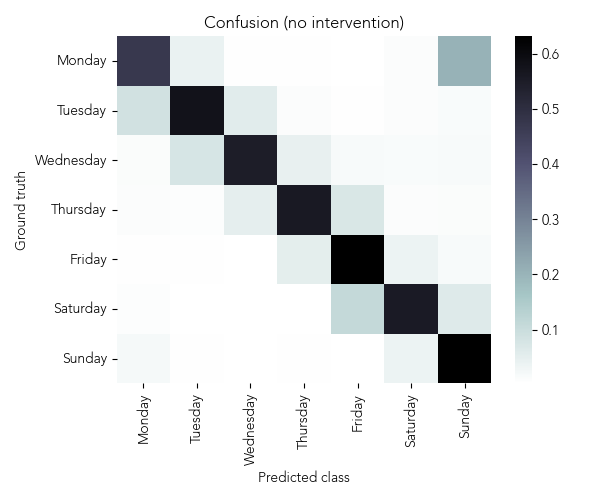

In [6]:
# Show the heatmap of the confusion matrix, with an extra column that aggregates the mass on task-unrelated tokens. 

from IPython.display import Image, display
with open(os.path.join(artifact_dir, 'confusion_heatmap.png')) as f:
    display(Image(filename=f.name))

For llama 3.1 8b, the confusion matrix shows a clear diagonal, where the model reliably distinguishes all classes. For llama 3.2 1b, the confusion matrix shows a more uniform distribution, where the model is more confused across classes.

## Layer localization

Now that we know llama 3.1 8b solves the task, we ask **where** in the residual stream the weekday variable is encoded.
The `locate` analysis patches activations from counterfactual inputs at each (layer, token_position) cell and measures how well the intervention recovers the expected causal effect.
See the `locate` demo notebook [[link]] for the full walkthrough; here we use the same config as the weekdays reference run.

In [7]:
# Define the locate config, save and load for printing

locate_config_yaml = """\
# @package _global_
defaults:
  - /base
  - /task: natural_domains_arithmetic_weekdays
  - /model: llama31_8b # llama32_1b_instruct cannot solve this task
  - /analysis/locate
  - _self_
task:
  enumerate_all: true # Enumerate all examples in the training set, test = []
  intervention_metric: string_match
  resample_variable: entity
  target_variable: result

locate:
  method: interchange
  mode: pairwise
  layers: [0, 8, 16, 18, 20, 24]
  n_steer: 16
  visualization:
    figure_format: png
"""

from omegaconf import OmegaConf
from causalab.io.configs import save_runner_config, load_runner_config

path = save_runner_config(locate_config_yaml, 'weekdays_locate_demo')
print(f'Written to {path}\n')

cfg = load_runner_config('weekdays_locate_demo')
print(f'Full hydra config:\n')
print(OmegaConf.to_yaml(cfg))

Written to /mnt/home/can.rager/causalab/causalab/configs/runners/demos/weekdays_locate_demo.yaml

Full hydra config:

seed: 42
experiment_root: artifacts/natural_domains_arithmetic/llama31_8b/weekdays
slurm:
  time: 04:00:00
task:
  name: natural_domains_arithmetic
  domain_type: weekdays
  variant: weekdays
  number_range: null
  number_groups: null
  max_new_tokens: 1
  colormap: rainbow
  colormap2: null
  intervention_metric: string_match
  reference_source: empirical
  n_train: 1000
  n_test: 50
  enumerate_all: true
  balanced: false
  resample_variable: entity
  distance_function: hellinger
  isometry:
    distance_function: ${task.distance_function}
    grid_range:
    - 0
    - 7
    grid_resolution: 150
    bin_positions: null
  target_variable: result
model:
  id: llama31_8b
  name: meta-llama/Llama-3.1-8B
  device: auto
  dtype: bfloat16
  slurm:
    gpus: 1
locate:
  _name_: locate
  _subdir: ${.method}
  _output_dir: ${experiment_root}/locate/${._subdir}
  method: interch

In [8]:
# Run the locate analysis
subprocess.run(
    ["bash", "scripts/run_exp.sh", "weekdays_locate_demo"],
    cwd=project_root,
)

[2026-05-05 16:17:41,513][__main__][INFO] - === Step: locate (locate) ===
[2026-05-05 16:17:51,541][causalab.io.pipelines][INFO] - Loading model: meta-llama/Llama-3.1-8B (device=cuda)


Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00, 145.27it/s]


[2026-05-05 16:17:55,100][causalab.analyses.locate.main][INFO] - Locate scan over variables: ['result']
[2026-05-05 16:17:55,101][causalab.analyses.locate.main][INFO] - === Locate: target_variable=result ===
[2026-05-05 16:17:55,108][causalab.runner.helpers][INFO] - Exhaustive enumeration: 49 unique input combinations (resample_variable=entity)
[2026-05-05 16:17:55,111][causalab.analyses.locate.run_interchange][INFO] - Loaded base accuracy from baseline: 91.8%
[2026-05-05 16:17:55,113][causalab.analyses.locate.run_interchange][INFO] - Loaded ref_dists from baseline: torch.Size([7, 7])
[2026-05-05 16:17:55,115][causalab.methods.interchange.layer_scan][INFO] - Collecting counterfactual output distributions...


Pairwise layer scan: 100%|██████████| 18/18 [00:04<00:00,  3.66it/s]


[2026-05-05 16:18:01,039][causalab.analyses.locate.main][INFO] - result: best cell = (layer=0, position=entity), score=0.9796
[2026-05-05 16:18:01,050][causalab.runner.helpers][INFO] - Exhaustive enumeration: 49 unique input combinations (resample_variable=entity)
[2026-05-05 16:18:13,858][causalab.analyses.locate.main][INFO] - Single-pair trace saved to artifacts/natural_domains_arithmetic/llama31_8b/weekdays/locate/interchange/single_pair_trace.json
[2026-05-05 16:18:14,269][causalab.analyses.locate.main][INFO] - Locate analysis complete. Output in artifacts/natural_domains_arithmetic/llama31_8b/weekdays/locate/interchange


CompletedProcess(args=['bash', 'scripts/run_exp.sh', 'weekdays_locate_demo'], returncode=0)

In [9]:
locate_artifact_dir = os.path.join(
    project_root, cfg.experiment_root, 'locate',
    cfg.locate.method,
)
print(f'Locate artifact directory: {locate_artifact_dir}\n')
print('Contents:', sorted(os.listdir(locate_artifact_dir)))

Locate artifact directory: /mnt/home/can.rager/causalab/artifacts/natural_domains_arithmetic/llama31_8b/weekdays/locate/interchange

Contents: ['metadata.json', 'result', 'results.json', 'single_pair_trace.json', 'single_pair_trace_heatmap.pdf', 'single_pair_trace_heatmap.png']


Base prompt:           Q: What day is one days after Monday?
A:
Counterfactual prompt: Q: What day is one days after Sunday?
A:



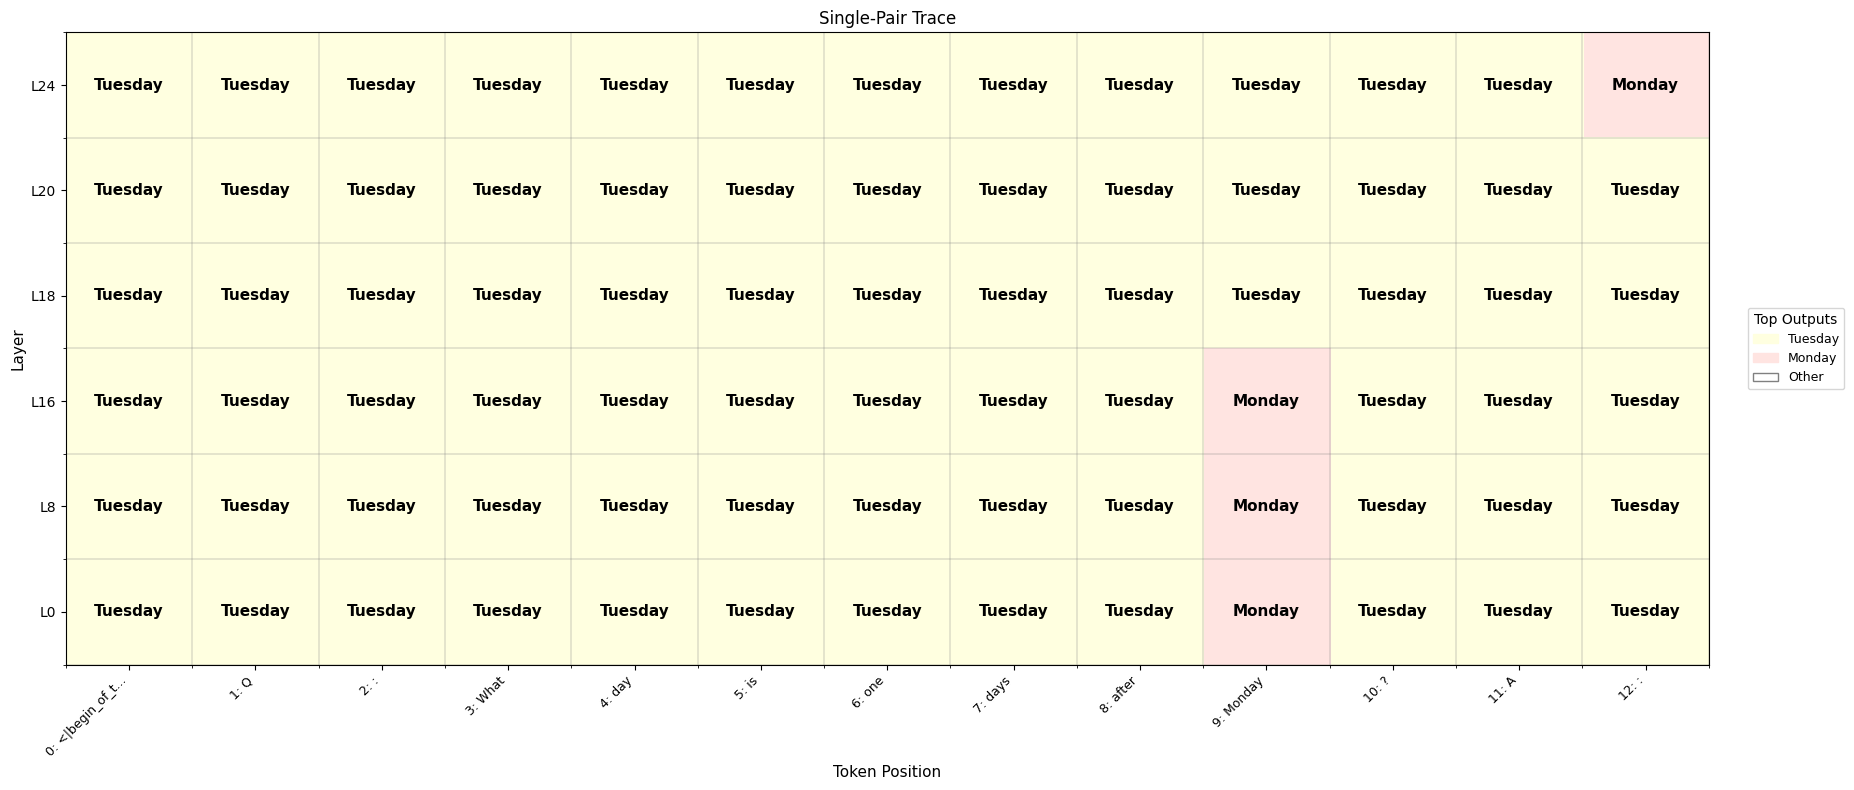

In [10]:
# Show the single-pair trace: what the model outputs at every (layer, token_position) when one counterfactual pair is patched.
# Look for where the signal "hops" from the input token to the last token across layers.

import json
from causalab.io.plots.string_heatmap import plot_single_pair_trace_heatmap

trace_path = os.path.join(locate_artifact_dir, 'single_pair_trace.json')
with open(trace_path) as f:
    trace_data = json.load(f)

print(f"Base prompt:           {trace_data['prompt']}")
print(f"Counterfactual prompt: {trace_data['counterfactual_prompt']}\n")

plot_single_pair_trace_heatmap(trace_data, figure_format='png')


--- result ---


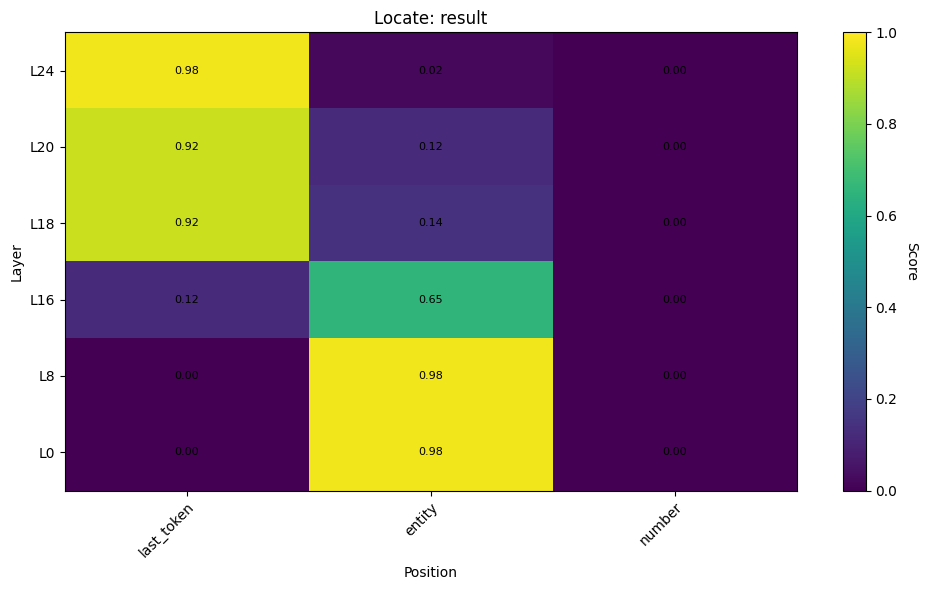

In [11]:
# Show the per-variable (layer x token_position) score heatmap. The brightest cell is the most localized site for the variable.

from glob import glob
from IPython.display import Image, display

for var_name in sorted(os.listdir(locate_artifact_dir)):
    var_dir = os.path.join(locate_artifact_dir, var_name)
    if not os.path.isdir(var_dir):
        continue
    matches = glob(os.path.join(var_dir, 'heatmap.png'))
    if matches:
        print(f'\n--- {var_name} ---')
        display(Image(filename=matches[0]))

The heatmap localizes the weekday variable to a small region of (layer, token_position) cells. Information enters at the entity token in early layers and is routed toward the last token, where the unembedding reads it out. This gives us the (layer, position) target for the next RQ — finding the low-dimensional subspace within that cell.

Now, we're specifically interested in patching centroids. (That's a choice in the paper, an even more principled choice would be at the data level.)
Before we were defining (base, source) counterfactual pairs, and checking whether the patch successfully steers model from base to source prediction,
Instead, we now compute centroids per result, and check whether intervening with a source activation from the robustly, regardless of the input. 
We are averaging out information about the entity and number, since each entity and number variable can be used to yield a specific result day. 
For example "Thursday" can result from ["Monday+3", "Tuesday+2", ...]. Therefore we only expect this patch to work on the final token.
NOTE this could be resolved by patching the variable specific centroid, instead always the "result_day" centroid for all variables. But centroid patching is rather imprecise anyways, so no need to put too much effort into it.

We're switching to centroid mode and resample all variables.

In [12]:
# Defining the centroid patching config.

locate_config_yaml = """\
# @package _global_
defaults:
  - /base
  - /task: natural_domains_arithmetic_weekdays
  - /model: llama31_8b # llama32_1b_instruct cannot solve this task
  - /analysis/locate
  - _self_
task:
  enumerate_all: true # Enumerate all examples in the training set, test = []
  intervention_metric: string_match
  resample_variable: all # <-- changing to all variables, since we don't use counterfactual pairs anyways, the centroids will be our counterfactual pairs.
  target_variable: result

locate:
  method: interchange
  mode: centroid # <-- changing to centroid mode
  layers: [0, 8, 16, 18, 20, 24]
  n_steer: 16
  visualization:
    figure_format: png
"""

from omegaconf import OmegaConf
from causalab.io.configs import save_runner_config, load_runner_config

path = save_runner_config(locate_config_yaml, 'weekdays_locate_demo')
print(f'Written to {path}\n')

cfg = load_runner_config('weekdays_locate_demo')
print(f'Full hydra config:\n')
print(OmegaConf.to_yaml(cfg))

Written to /mnt/home/can.rager/causalab/causalab/configs/runners/demos/weekdays_locate_demo.yaml

Full hydra config:

seed: 42
experiment_root: artifacts/natural_domains_arithmetic/llama31_8b/weekdays
slurm:
  time: 04:00:00
task:
  name: natural_domains_arithmetic
  domain_type: weekdays
  variant: weekdays
  number_range: null
  number_groups: null
  max_new_tokens: 1
  colormap: rainbow
  colormap2: null
  intervention_metric: string_match
  reference_source: empirical
  n_train: 1000
  n_test: 50
  enumerate_all: true
  balanced: false
  resample_variable: all
  distance_function: hellinger
  isometry:
    distance_function: ${task.distance_function}
    grid_range:
    - 0
    - 7
    grid_resolution: 150
    bin_positions: null
  target_variable: result
model:
  id: llama31_8b
  name: meta-llama/Llama-3.1-8B
  device: auto
  dtype: bfloat16
  slurm:
    gpus: 1
locate:
  _name_: locate
  _subdir: ${.method}
  _output_dir: ${experiment_root}/locate/${._subdir}
  method: interchang

In [13]:
# Re-run the locate analysis
subprocess.run(
    ["bash", "scripts/run_exp.sh", "weekdays_locate_demo"],
    cwd=project_root,
)

[2026-05-05 16:18:27,489][__main__][INFO] - === Step: locate (locate) ===
[2026-05-05 16:18:39,366][causalab.io.pipelines][INFO] - Loading model: meta-llama/Llama-3.1-8B (device=cuda)


Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00, 142.79it/s]


[2026-05-05 16:18:42,868][causalab.analyses.locate.main][INFO] - Locate scan over variables: ['result']
[2026-05-05 16:18:42,869][causalab.analyses.locate.main][INFO] - === Locate: target_variable=result ===
[2026-05-05 16:18:42,876][causalab.runner.helpers][INFO] - Exhaustive enumeration: 49 unique input combinations (resample_variable=all)
[2026-05-05 16:18:42,879][causalab.analyses.locate.run_interchange][INFO] - Loaded base accuracy from baseline: 91.8%
[2026-05-05 16:18:42,880][causalab.analyses.locate.run_interchange][INFO] - Loaded ref_dists from baseline: torch.Size([7, 7])


Centroid layer scan: 100%|██████████| 18/18 [00:07<00:00,  2.33it/s]


Saved figure to artifacts/natural_domains_arithmetic/llama31_8b/weekdays/locate/interchange/result/L0/Plast_token/patched_dim0.png
[2026-05-05 16:18:51,534][causalab.analyses.path_steering.path_visualization][INFO] - Saved ground truth line plot: artifacts/natural_domains_arithmetic/llama31_8b/weekdays/locate/interchange/result/L0/Plast_token/patched_dim0.png
Saved figure to artifacts/natural_domains_arithmetic/llama31_8b/weekdays/locate/interchange/result/L0/Pentity/patched_dim0.png
[2026-05-05 16:18:51,774][causalab.analyses.path_steering.path_visualization][INFO] - Saved ground truth line plot: artifacts/natural_domains_arithmetic/llama31_8b/weekdays/locate/interchange/result/L0/Pentity/patched_dim0.png
Saved figure to artifacts/natural_domains_arithmetic/llama31_8b/weekdays/locate/interchange/result/L0/Pnumber/patched_dim0.png
[2026-05-05 16:18:52,004][causalab.analyses.path_steering.path_visualization][INFO] - Saved ground truth line plot: artifacts/natural_domains_arithmetic/llam

CompletedProcess(args=['bash', 'scripts/run_exp.sh', 'weekdays_locate_demo'], returncode=0)


--- result ---


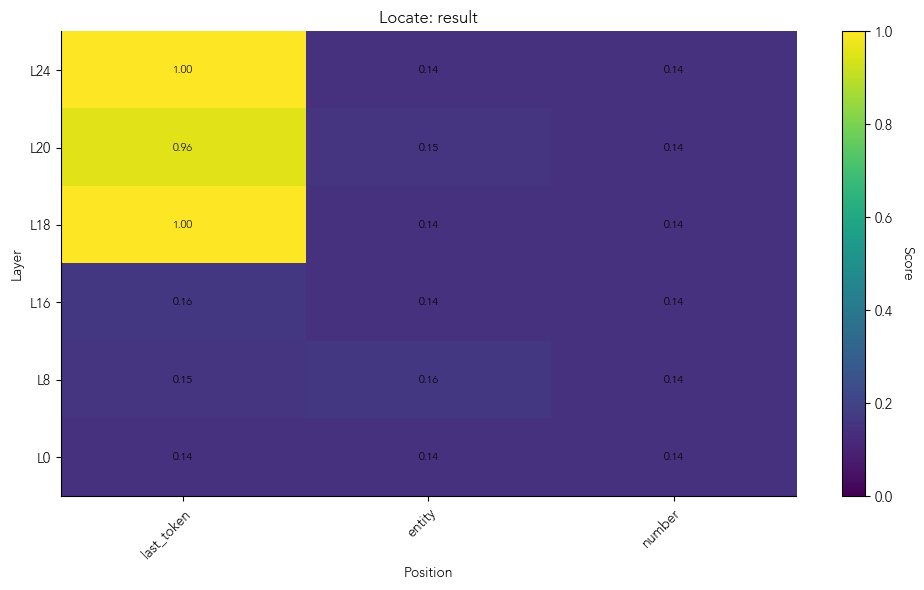

In [14]:
# Show the per-variable (layer x token_position) score heatmap. The brightest cell is the most localized site for the variable.

from glob import glob
from IPython.display import Image, display

locate_artifact_dir = os.path.join(
    project_root, cfg.experiment_root, 'locate',
    cfg.locate.method,
)

for var_name in sorted(os.listdir(locate_artifact_dir)):
    var_dir = os.path.join(locate_artifact_dir, var_name)
    if not os.path.isdir(var_dir):
        continue
    matches = glob(os.path.join(var_dir, 'heatmap.png'))
    if matches:
        print(f'\n--- {var_name} ---')
        display(Image(filename=matches[0]))

Okay great, we've learned that centroid intervention already works at the final token position at layer 18. Let's fix our following investigation to this site in the model.
Next, we want to identify whether a low-dimensional subspace captures most variance

## Subspace localization

"Subspace that captures most variance" can mean two (or more?) things each requiring its own tool: 
- **Input variance:** Subspace that captures most variance of activations for all inputs --> PCA
- **Output variance:** Subspace that is most causally relevant to flip a model prediction from the base answer to a counterfactual source answer.

In the end we are concerned with steering model behavior, so causal efficacy is highly relevant and DAS is a suitable tool.
However, in our current approach we are patching centrids over all inputs and don't define counterfactual pairs, so PCA is a natural choice for subspace identification with this approach.

Natural domains arithmetic weekdays task with llama31_8b

In [15]:
config_yaml = """\
# @package _global_
defaults:
  - /base
  - /task: natural_domains_arithmetic_weekdays
  - /model: llama31_8b
  - /analysis/subspace
  - _self_
task:
  enumerate_all: true # training on all possible examples, test = train
  target_variable: result

subspace:
  method: pca
  layers: [28]
  k_features: 32
  token_positions: [last_token]
  visualization:
    figure_format: png
"""


save_runner_config(config_yaml, 'weekdays_subspace_demo')
cfg = load_runner_config('weekdays_subspace_demo')
print(f'Full hydra config:\n', OmegaConf.to_yaml(cfg))

Full hydra config:
 seed: 42
experiment_root: artifacts/natural_domains_arithmetic/llama31_8b/weekdays
slurm:
  time: 04:00:00
task:
  name: natural_domains_arithmetic
  domain_type: weekdays
  variant: weekdays
  number_range: null
  number_groups: null
  max_new_tokens: 1
  colormap: rainbow
  colormap2: null
  intervention_metric: kl
  reference_source: empirical
  n_train: 1000
  n_test: 50
  enumerate_all: true
  balanced: false
  resample_variable: all
  distance_function: hellinger
  isometry:
    distance_function: ${task.distance_function}
    grid_range:
    - 0
    - 7
    grid_resolution: 150
    bin_positions: null
  target_variable: result
model:
  id: llama31_8b
  name: meta-llama/Llama-3.1-8B
  device: auto
  dtype: bfloat16
  slurm:
    gpus: 1
subspace:
  _name_: subspace
  _subdir: ${.method}_k${.k_features}
  _output_dir: ${experiment_root}/subspace/${._subdir}
  method: pca
  k_features: 32
  batch_size: 32
  component_type: residual_stream
  layers:
  - 28
  token

In [16]:
subprocess.run(
    ["bash", "scripts/run_exp.sh", "weekdays_subspace_demo"],
    cwd=project_root
)

[2026-05-05 16:19:11,784][__main__][INFO] - === Step: subspace (subspace) ===
[2026-05-05 16:19:20,891][__main__][INFO] - Running analysis: subspace | target_variable: result
[2026-05-05 16:19:20,894][__main__][INFO] - Resolved config:
seed: 42
experiment_root: artifacts/natural_domains_arithmetic/llama31_8b/weekdays
slurm:
  time: 04:00:00
task:
  name: natural_domains_arithmetic
  domain_type: weekdays
  variant: weekdays
  number_range: null
  number_groups: null
  max_new_tokens: 1
  colormap: rainbow
  colormap2: null
  intervention_metric: kl
  reference_source: empirical
  n_train: 1000
  n_test: 50
  enumerate_all: true
  balanced: false
  resample_variable: all
  distance_function: hellinger
  isometry:
    distance_function: ${task.distance_function}
    grid_range:
    - 0
    - 7
    grid_resolution: 150
    bin_positions: null
  target_variable: result
model:
  id: llama31_8b
  name: meta-llama/Llama-3.1-8B
  device: auto
  dtype: bfloat16
  slurm:
    gpus: 1
subspace:
  

Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00, 141.56it/s]


[2026-05-05 16:19:24,844][causalab.analyses.subspace.pca][INFO] - Computing PCA with k=32...


[2026-05-05 16:19:25,838][causalab.analyses.subspace.pca][INFO] - PCA variance explained: ['16.8%', '14.8%', '12.8%', '7.4%', '6.3%', '5.3%', '4.1%', '3.8%', '3.6%', '2.6%', '2.4%', '2.0%', '1.9%', '1.6%', '1.5%', '1.4%', '1.2%', '1.1%', '1.0%', '0.8%', '0.8%', '0.7%', '0.7%', '0.6%', '0.5%', '0.5%', '0.4%', '0.3%', '0.3%', '0.3%', '0.3%', '0.2%'], total: 98.0%
[2026-05-05 16:19:25,948][causalab.methods.spline.builders][INFO] - Computed 7 centroids from 49 samples (params: ['result'])
[2026-05-05 16:19:26,572][causalab.io.plots.plot_3d_interactive][INFO] - Saved artifacts/natural_domains_arithmetic/llama31_8b/weekdays/subspace/pca_k32/result/visualization/features_3d.html
[2026-05-05 16:19:26,572][causalab.analyses.subspace._visualization][INFO] - Saved features_3d.html to artifacts/natural_domains_arithmetic/llama31_8b/weekdays/subspace/pca_k32/result/visualization
[2026-05-05 16:19:26,575][causalab.methods.spline.builders][INFO] - Computed 7 centroids from 49 samples (params: ['resul

CompletedProcess(args=['bash', 'scripts/run_exp.sh', 'weekdays_subspace_demo'], returncode=0)

In [17]:
# Locate subspace artifact directory.
# Outputs are nested under <step>/<method_subdir>/<target_variable>/...
subspace_artifact_dir = os.path.join(
    project_root, cfg.experiment_root, 'subspace',
    f"{cfg.subspace.method}_k{cfg.subspace.k_features}",
    cfg.task.target_variable,
)
vis_dir = os.path.join(subspace_artifact_dir, 'visualization')
print(f'Visualization directory: {vis_dir}')
print('Contents:', sorted(os.listdir(vis_dir)))

Visualization directory: /mnt/home/can.rager/causalab/artifacts/natural_domains_arithmetic/llama31_8b/weekdays/subspace/pca_k32/result/visualization
Contents: ['features_2d.pdf', 'features_2d.png', 'features_3d.html', 'features_3d.pdf', 'features_3d.png', 'features_variance.pdf', 'features_variance.png']


### Variance explained by the PCA subspace

Each bar shows the **cumulative** variance explained by the first k principal components,
as a fraction of the **total variance of the full embedding space** — the denominator is
the sum of all singular values squared, not just the k-component subspace.
A steep early rise means the representation is intrinsically low-dimensional.
The dashed line marks how much total variance the chosen k_features subspace retains.

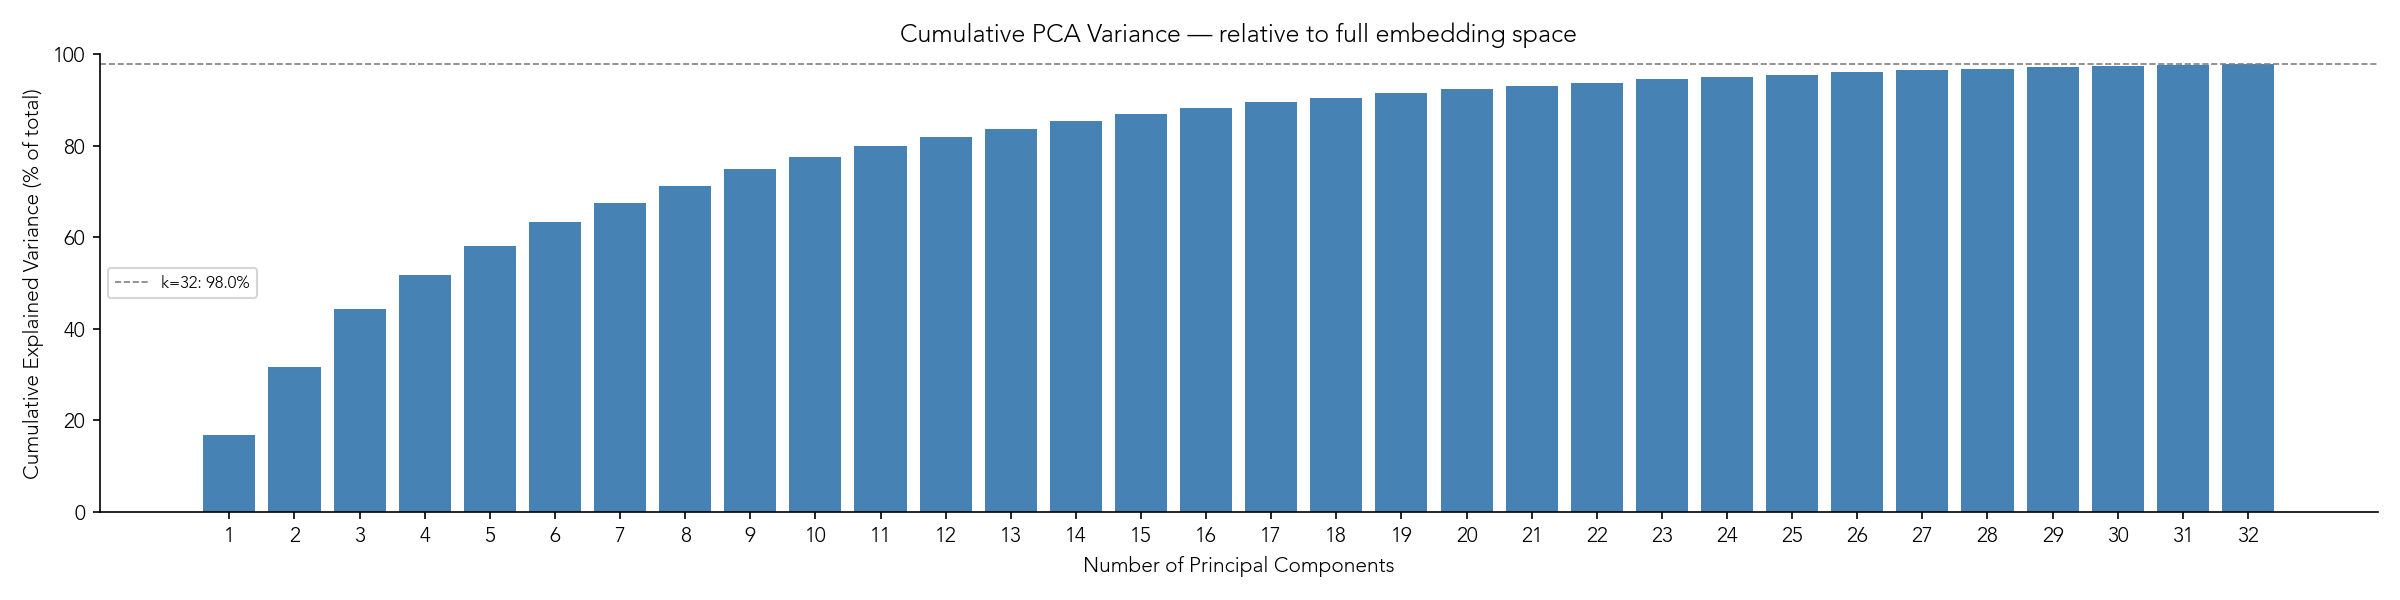

In [18]:
# Cumulative explained variance vs. number of PCs
display(Image(filename=os.path.join(vis_dir, 'features_variance.png')))

Looking at the distribution of variance captured by principal components, we could already define a cutoff at `k_features=16`.

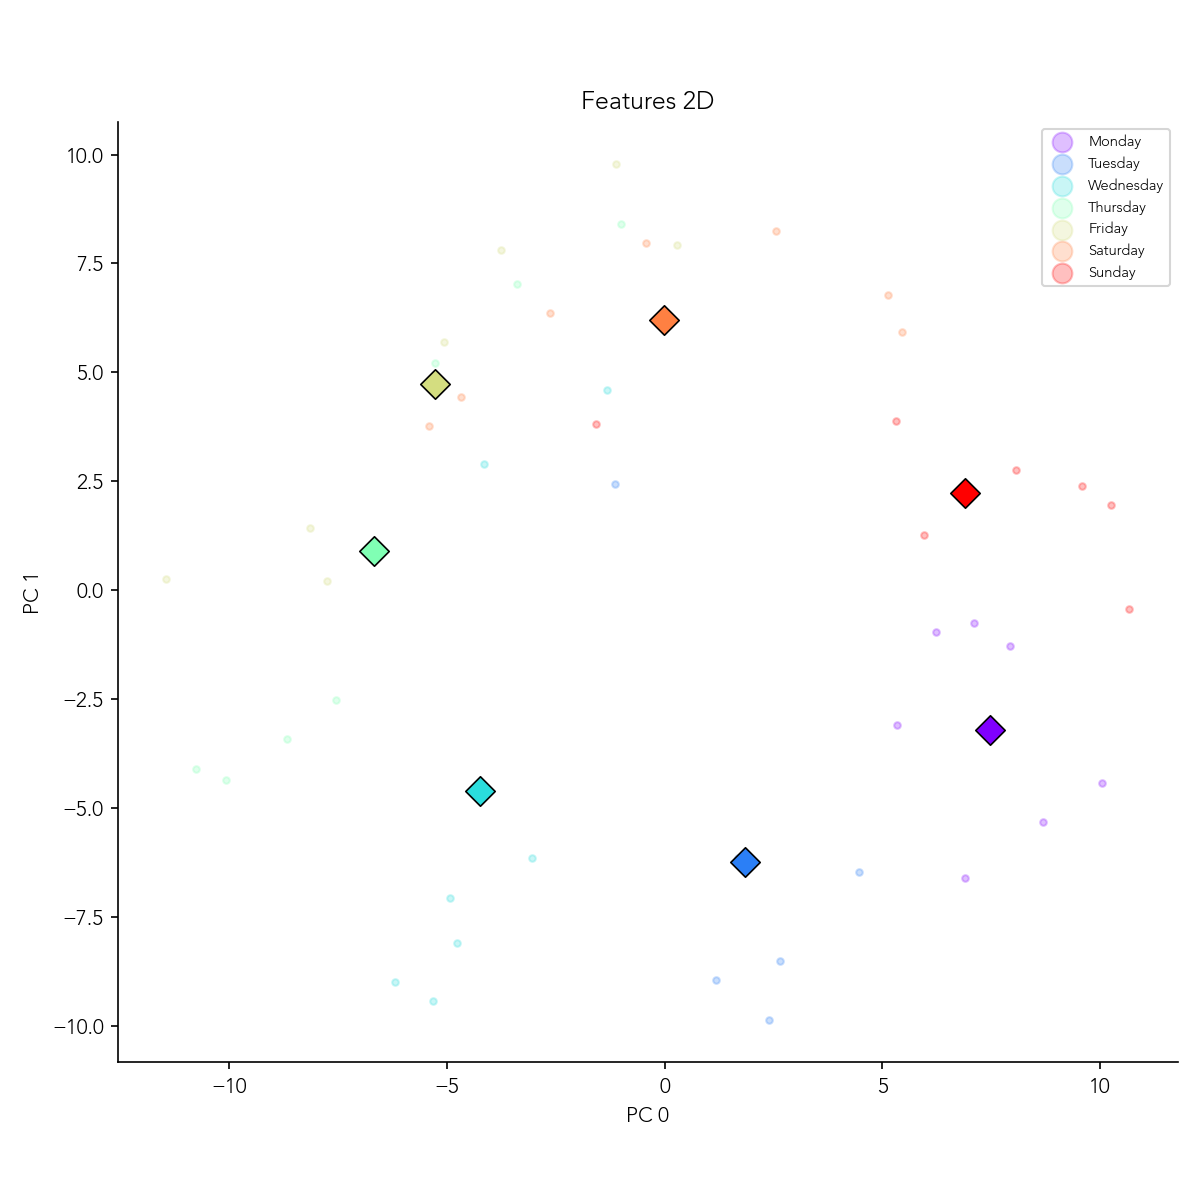

In [19]:
# 2D PCA scatter: training examples colored by weekday
display(Image(filename=os.path.join(vis_dir, 'features_2d.png')))

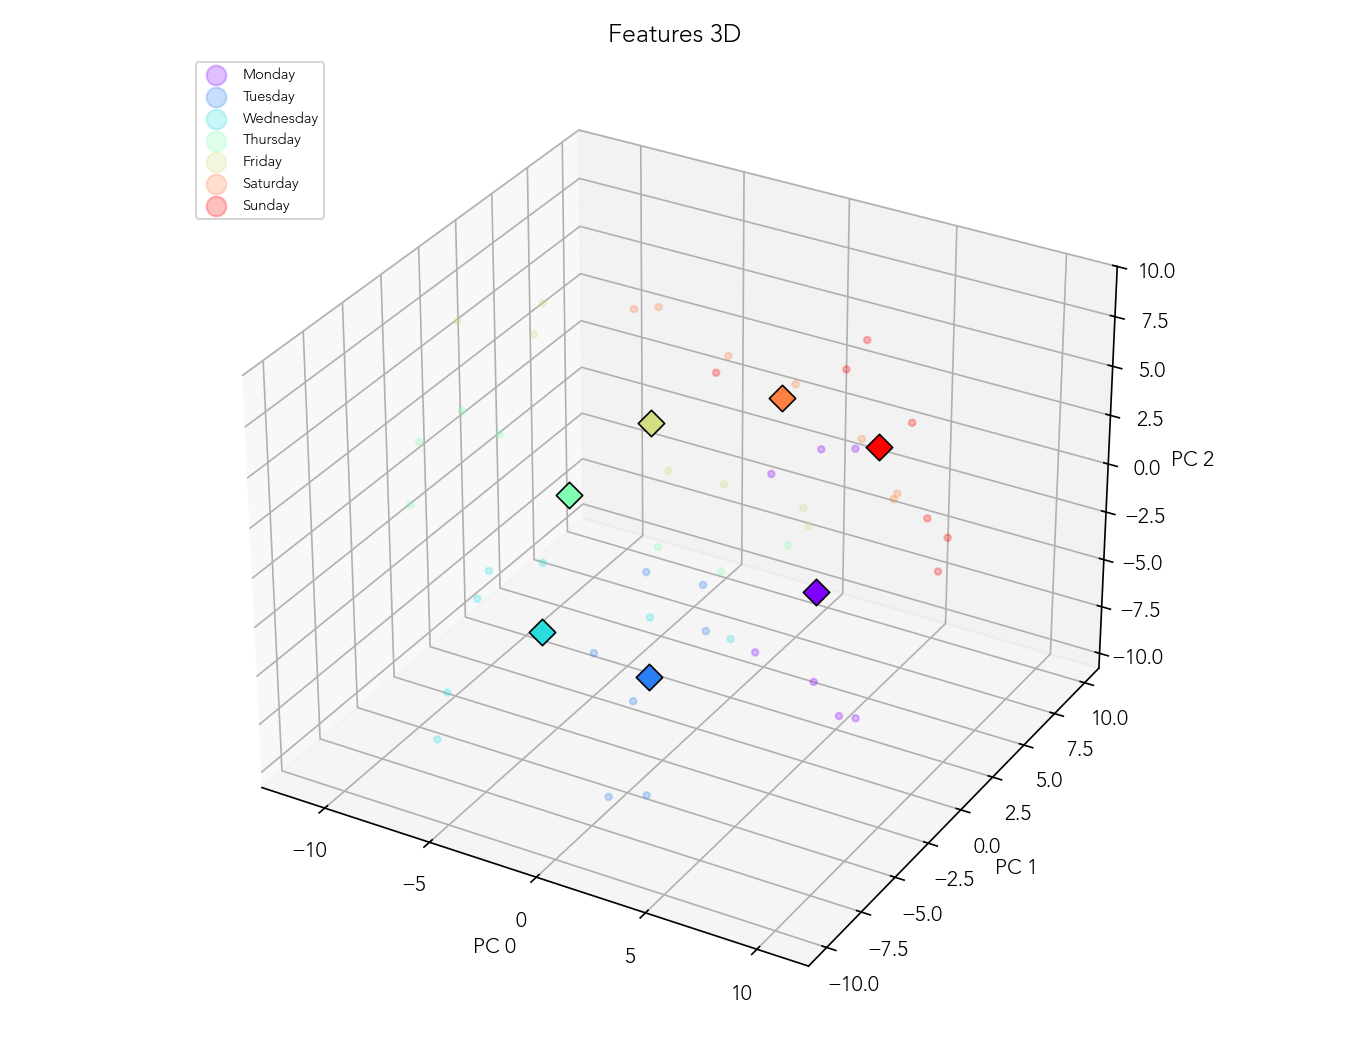

In [20]:
# Static 3D PCA scatter (matplotlib): PC0 x PC1 x PC2
display(Image(filename=os.path.join(vis_dir, 'features_3d.png')))

At layer 18 (where `locate` confirmed causal encoding of the result variable with score 1.0), the 7 result-day centroids are clearly separated and form a circular structure in PCA space. The centroid geometry looks like a circle! Let's fit a 1D spline to enable geometric steering.

**Why layer 18, not later layers?**  
At deeper layers (e.g. layer 28), the `last_token` residual stream is dominated by the *number* variable: all 7 examples sharing the same shift amount have nearly identical activations. Because each result class spans all 7 number values uniformly (e.g. result=Monday = {Mon+7, Tue+6, Wed+5, …}), every result centroid collapses to the PCA global mean — a mathematical identity, not a code bug. Layer 18 is where the result variable is causally encoded before this collapse occurs.

## Activation manifold fitting

We'll use thin plate splines to adaptively fit a circle. 

In [21]:
config_yaml = """\
# @package _global_
defaults:
  - /base
  - /task: natural_domains_arithmetic_weekdays
  - /model: llama31_8b
  - /analysis/activation_manifold
  - _self_
task:
  target_variable: result
activation_manifold:
  manifold_intrinsic_coords: parameter
  method: spline
  smoothness: 0.0
  subspace: pca_k32
  k_features: 32
  skip_decoding_eval: false
  layers: [28]
  token_positions: [last_token]
  visualization:
    figure_format: png
""" 

save_runner_config(config_yaml, 'weekdays_activation_manifold_demo')
cfg = load_runner_config('weekdays_activation_manifold_demo')
print(f'Full hydra config:\n', OmegaConf.to_yaml(cfg))

Full hydra config:
 seed: 42
experiment_root: artifacts/natural_domains_arithmetic/llama31_8b/weekdays
slurm:
  time: 04:00:00
task:
  name: natural_domains_arithmetic
  domain_type: weekdays
  variant: weekdays
  number_range: null
  number_groups: null
  max_new_tokens: 1
  colormap: rainbow
  colormap2: null
  intervention_metric: kl
  reference_source: empirical
  n_train: 1000
  n_test: 50
  enumerate_all: true
  balanced: false
  resample_variable: all
  distance_function: hellinger
  isometry:
    distance_function: ${task.distance_function}
    grid_range:
    - 0
    - 7
    grid_resolution: 150
    bin_positions: null
  target_variable: result
model:
  id: llama31_8b
  name: meta-llama/Llama-3.1-8B
  device: auto
  dtype: bfloat16
  slurm:
    gpus: 1
activation_manifold:
  _name_: activation_manifold
  _subdir: ${.method}_s${.smoothness}
  _output_dir: ${experiment_root}/activation_manifold/${._subdir}
  method: spline
  smoothness: 0.0
  spline_method: auto
  intrinsic_dim:

In [22]:
subprocess.run(
    ["bash", "scripts/run_exp.sh", "weekdays_activation_manifold_demo"],
    cwd=project_root,
)

[2026-05-05 16:19:29,657][__main__][INFO] - === Step: activation_manifold (activation_manifold) ===
[2026-05-05 16:19:40,472][__main__][INFO] - Running analysis: activation_manifold | target_variable: result
[2026-05-05 16:19:40,475][__main__][INFO] - Resolved config:
seed: 42
experiment_root: artifacts/natural_domains_arithmetic/llama31_8b/weekdays
slurm:
  time: 04:00:00
task:
  name: natural_domains_arithmetic
  domain_type: weekdays
  variant: weekdays
  number_range: null
  number_groups: null
  max_new_tokens: 1
  colormap: rainbow
  colormap2: null
  intervention_metric: kl
  reference_source: empirical
  n_train: 1000
  n_test: 50
  enumerate_all: true
  balanced: false
  resample_variable: all
  distance_function: hellinger
  isometry:
    distance_function: ${task.distance_function}
    grid_range:
    - 0
    - 7
    grid_resolution: 150
    bin_positions: null
  target_variable: result
model:
  id: llama31_8b
  name: meta-llama/Llama-3.1-8B
  device: auto
  dtype: bfloat16


Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00, 135.53it/s]


[2026-05-05 16:19:44,653][causalab.analyses.activation_manifold.main][INFO] - Model loading: 4.0s
[2026-05-05 16:19:44,655][causalab.analyses.activation_manifold.main][INFO] - === Manifold for subspace pca_k32 ===
[2026-05-05 16:19:45,079][causalab.analyses.subspace.loading][INFO] - Loaded PCA rotation from artifacts/natural_domains_arithmetic/llama31_8b/weekdays/subspace/pca_k32/result/rotation.safetensors
[2026-05-05 16:19:45,087][causalab.analyses.activation_manifold.main][INFO] - Loaded saved subspace dataset: 49 examples
[2026-05-05 16:19:45,090][causalab.analyses.activation_manifold.main][INFO] - Loaded ref_dists from baseline
[2026-05-05 16:19:45,091][causalab.analyses.activation_manifold.fitting_pipeline][INFO] - Auto-detected intrinsic_dim=1
[2026-05-05 16:19:45,091][causalab.analyses.activation_manifold.fitting_pipeline][INFO] - Starting manifold fitting pipeline: k=32, d=1, method=spline
[2026-05-05 16:19:45,093][causalab.analyses.activation_manifold.fitting_pipeline][INFO] 

CompletedProcess(args=['bash', 'scripts/run_exp.sh', 'weekdays_activation_manifold_demo'], returncode=0)

In [23]:
# Find the manifold_3d.png — artifact dir is nested under activation_manifold/
from glob import glob

manifold_pngs = sorted(glob(os.path.join(
    project_root, cfg.experiment_root, 'activation_manifold',
    '**', 'visualization', 'manifold_3d.png',
), recursive=True))
print('Found:', manifold_pngs)

Found: ['/mnt/home/can.rager/causalab/artifacts/natural_domains_arithmetic/llama31_8b/weekdays/activation_manifold/pca_k32/L28_last_token/spline_s0.0/result/visualization/manifold_3d.png']


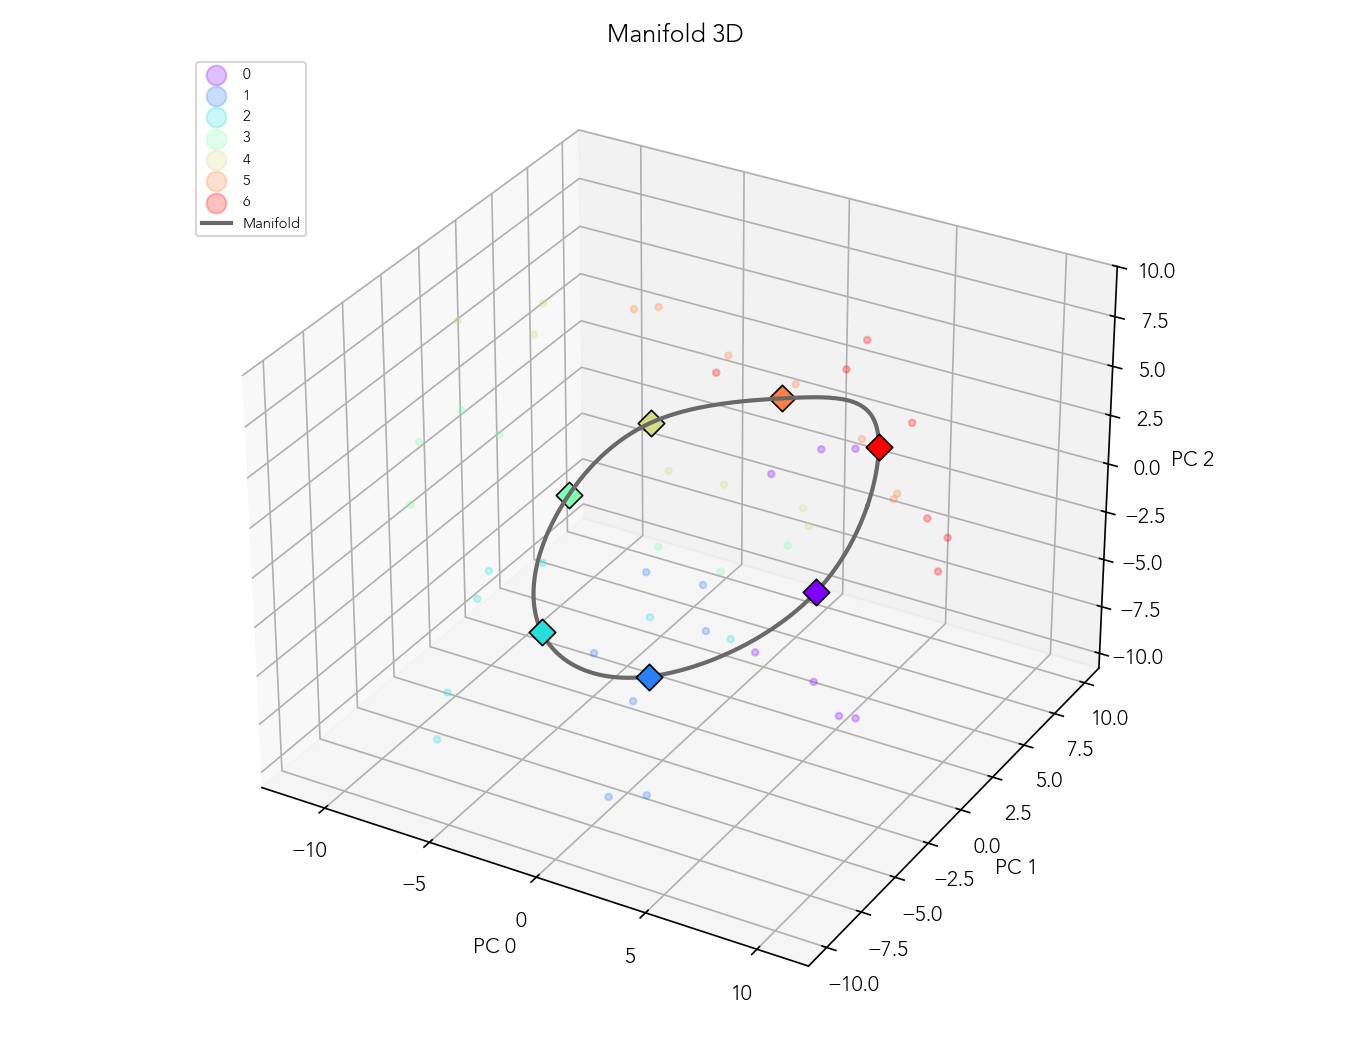

In [24]:
# Static 3D manifold: scatter colored by weekday + fitted spline curve
display(Image(filename=manifold_pngs[0]))

Because the manifold is a continuous spline, we can steer the model to any point along it —
intrinsic-space positions between each consecutive centroid pair (Mon→Tue, Tue→Wed, …)
give us evenly-spaced steering targets across the full ring. This manifold-traversal
evaluation is now produced by the **`path_steering`** analysis (the natural follow-up to
`activation_manifold`); its heatmaps show how each weekday token's output probability
evolves as we walk the manifold — a direct diagnostic for spline smoothness between classes.
Re-run with `path_steering` in the runner config to regenerate this section.

In [25]:
# Continuous manifold steering: x-axis labels show weekday names at centroid positions;
# unlabelled ticks between them are interpolated intrinsic-space positions.

steering_pngs = sorted(glob(os.path.join(
    project_root, cfg.experiment_root, 'activation_manifold',
    '**', 'manifold_steering', 'manifold_steering_dim0.png',
), recursive=True))
print('Found:', steering_pngs)

if steering_pngs:
    display(Image(filename=steering_pngs[0]))

Found: []


## Path steering: geodesic vs linear

With the activation manifold fitted, we steer the model from Monday to Thursday along two paths:
- **Geodesic**: follows the fitted spline in intrinsic coordinates — stays on the manifold
- **Linear**: straight line between the two centroids in PCA space — cuts through embedding space

We restrict to a single pair (Monday → Thursday) to compare the output distributions produced by each path.

In [32]:
config_yaml = """\
# @package _global_
defaults:
  - /base
  - /task: natural_domains_arithmetic_weekdays
  - /model: llama31_8b
  - /analysis/path_steering
  - _self_
task:
  target_variable: result
path_steering:
  subspace: pca_k32
  # Include the L{layer}_{token_position} cell-segment that
  # activation_manifold writes when token_positions is set, so the loader
  # finds the spline featurizer instead of falling back to identity.
  activation_manifold: L28_last_token/spline_s0.0
  selected_pairs: [["Monday", "Thursday"]]
  path_modes: [geometric, linear]
  visualization:
    figure_format: png
"""

save_runner_config(config_yaml, 'weekdays_path_steering_demo')
cfg_ps = load_runner_config('weekdays_path_steering_demo')
print('Full hydra config:\n', OmegaConf.to_yaml(cfg_ps))

Full hydra config:
 seed: 42
experiment_root: artifacts/natural_domains_arithmetic/llama31_8b/weekdays
slurm:
  time: 04:00:00
task:
  name: natural_domains_arithmetic
  domain_type: weekdays
  variant: weekdays
  number_range: null
  number_groups: null
  max_new_tokens: 1
  colormap: rainbow
  colormap2: null
  intervention_metric: kl
  reference_source: empirical
  n_train: 1000
  n_test: 50
  enumerate_all: true
  balanced: false
  resample_variable: all
  distance_function: hellinger
  isometry:
    distance_function: ${task.distance_function}
    grid_range:
    - 0
    - 7
    grid_resolution: 150
    bin_positions: null
  target_variable: result
model:
  id: llama31_8b
  name: meta-llama/Llama-3.1-8B
  device: auto
  dtype: bfloat16
  slurm:
    gpus: 1
path_steering:
  _name_: path_steering
  _output_dir: ${experiment_root}/path_steering
  eval_criteria:
  - isometry
  - coherence
  - distance_from_behavior_manifold
  path_modes:
  - geometric
  - linear
  selected_pairs:
  - 

In [33]:
subprocess.run(
    ["bash", "scripts/run_exp.sh", "weekdays_path_steering_demo"],
    cwd=project_root,
)

[2026-05-05 16:40:42,132][__main__][INFO] - === Step: path_steering (path_steering) ===
[2026-05-05 16:40:54,291][__main__][INFO] - Running analysis: path_steering | target_variable: result
[2026-05-05 16:40:54,294][__main__][INFO] - Resolved config:
seed: 42
experiment_root: artifacts/natural_domains_arithmetic/llama31_8b/weekdays
slurm:
  time: 04:00:00
task:
  name: natural_domains_arithmetic
  domain_type: weekdays
  variant: weekdays
  number_range: null
  number_groups: null
  max_new_tokens: 1
  colormap: rainbow
  colormap2: null
  intervention_metric: kl
  reference_source: empirical
  n_train: 1000
  n_test: 50
  enumerate_all: true
  balanced: false
  resample_variable: all
  distance_function: hellinger
  isometry:
    distance_function: ${task.distance_function}
    grid_range:
    - 0
    - 7
    grid_resolution: 150
    bin_positions: null
  target_variable: result
model:
  id: llama31_8b
  name: meta-llama/Llama-3.1-8B
  device: auto
  dtype: bfloat16
  slurm:
    gpus:

Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00, 148.31it/s]


[2026-05-05 16:40:58,486][causalab.analyses.path_steering.main][INFO] - === Evaluating pca_k32 / L28_last_token/spline_s0.0 ===
[2026-05-05 16:40:59,203][causalab.analyses.path_steering.main][WARNING] - selected_pairs is set — computing only the 1 named pair(s); aggregate criteria summaries (results_summary.csv, paired_ttest_*.json, criteria/*/metrics.json, isometry) will be skipped (cherry-picked subset cannot yield unbiased stats).
[2026-05-05 16:40:59,203][causalab.analyses.path_steering.main][INFO] - Path steering: 1 pair(s) selected (21 total possible)
[2026-05-05 16:40:59,223][causalab.analyses.path_steering.main][INFO] - === Path mode: geometric ===


[2026-05-05 16:41:11,276][causalab.analyses.path_steering.main][INFO] - Collected pair distributions: torch.Size([1, 50, 16, 7])
Saved figure to artifacts/natural_domains_arithmetic/llama31_8b/weekdays/path_steering/pca_k32/L28_last_token/spline_s0.0/result/vis/paths/geometric/pair_Monday_Thursday.png
[2026-05-05 16:41:12,399][causalab.analyses.path_steering.path_visualization][INFO] - Saved 1 path visualizations to artifacts/natural_domains_arithmetic/llama31_8b/weekdays/path_steering/pca_k32/L28_last_token/spline_s0.0/result/vis/paths/geometric
[2026-05-05 16:41:12,399][causalab.analyses.path_steering.main][INFO] - === Path mode: linear ===


[2026-05-05 16:41:22,011][causalab.analyses.path_steering.main][INFO] - Collected pair distributions: torch.Size([1, 50, 16, 7])
Saved figure to artifacts/natural_domains_arithmetic/llama31_8b/weekdays/path_steering/pca_k32/L28_last_token/spline_s0.0/result/vis/paths/linear/pair_Monday_Thursday.png
[2026-05-05 16:41:22,269][causalab.analyses.path_steering.path_visualization][INFO] - Saved 1 path visualizations to artifacts/natural_domains_arithmetic/llama31_8b/weekdays/path_steering/pca_k32/L28_last_token/spline_s0.0/result/vis/paths/linear
[2026-05-05 16:41:22,270][causalab.analyses.path_steering.main][INFO] - Skipping belief-space paths (missing output_manifold artifacts)
[2026-05-05 16:41:22,272][causalab.analyses.activation_manifold.utils][INFO] - Intrinsic ranges (99.7% coverage): dim0=[0.000, 6.283]
[2026-05-05 16:41:22,276][causalab.methods.spline.builders][INFO] - Computed 7 centroids from 49 samples (params: ['result'])
[2026-05-05 16:41:22,605][causalab.io.plots.plot_3d_inter

CompletedProcess(args=['bash', 'scripts/run_exp.sh', 'weekdays_path_steering_demo'], returncode=0)

In [34]:
# Path-steering artifacts are nested under <subspace>/<manifold>/<target_variable>/...
ps_out_dir = os.path.join(
    project_root, cfg_ps.experiment_root,
    'path_steering',
    cfg_ps.path_steering.subspace,
    cfg_ps.path_steering.activation_manifold,
    cfg_ps.task.target_variable,
)

In [35]:
# 3D PCA space: geodesic (black) vs linear (gray) path from Monday to Thursday.
# The 3D plot is saved as an interactive HTML (plotly), not a static image.
from IPython.display import IFrame
path_3d_html = os.path.join(ps_out_dir, 'vis', 'paths', '3d_paths', 'Monday_Thursday.html')
print(path_3d_html)
IFrame(src=path_3d_html, width='100%', height=600)

/mnt/home/can.rager/causalab/artifacts/natural_domains_arithmetic/llama31_8b/weekdays/path_steering/pca_k32/L28_last_token/spline_s0.0/result/vis/paths/3d_paths/Monday_Thursday.html


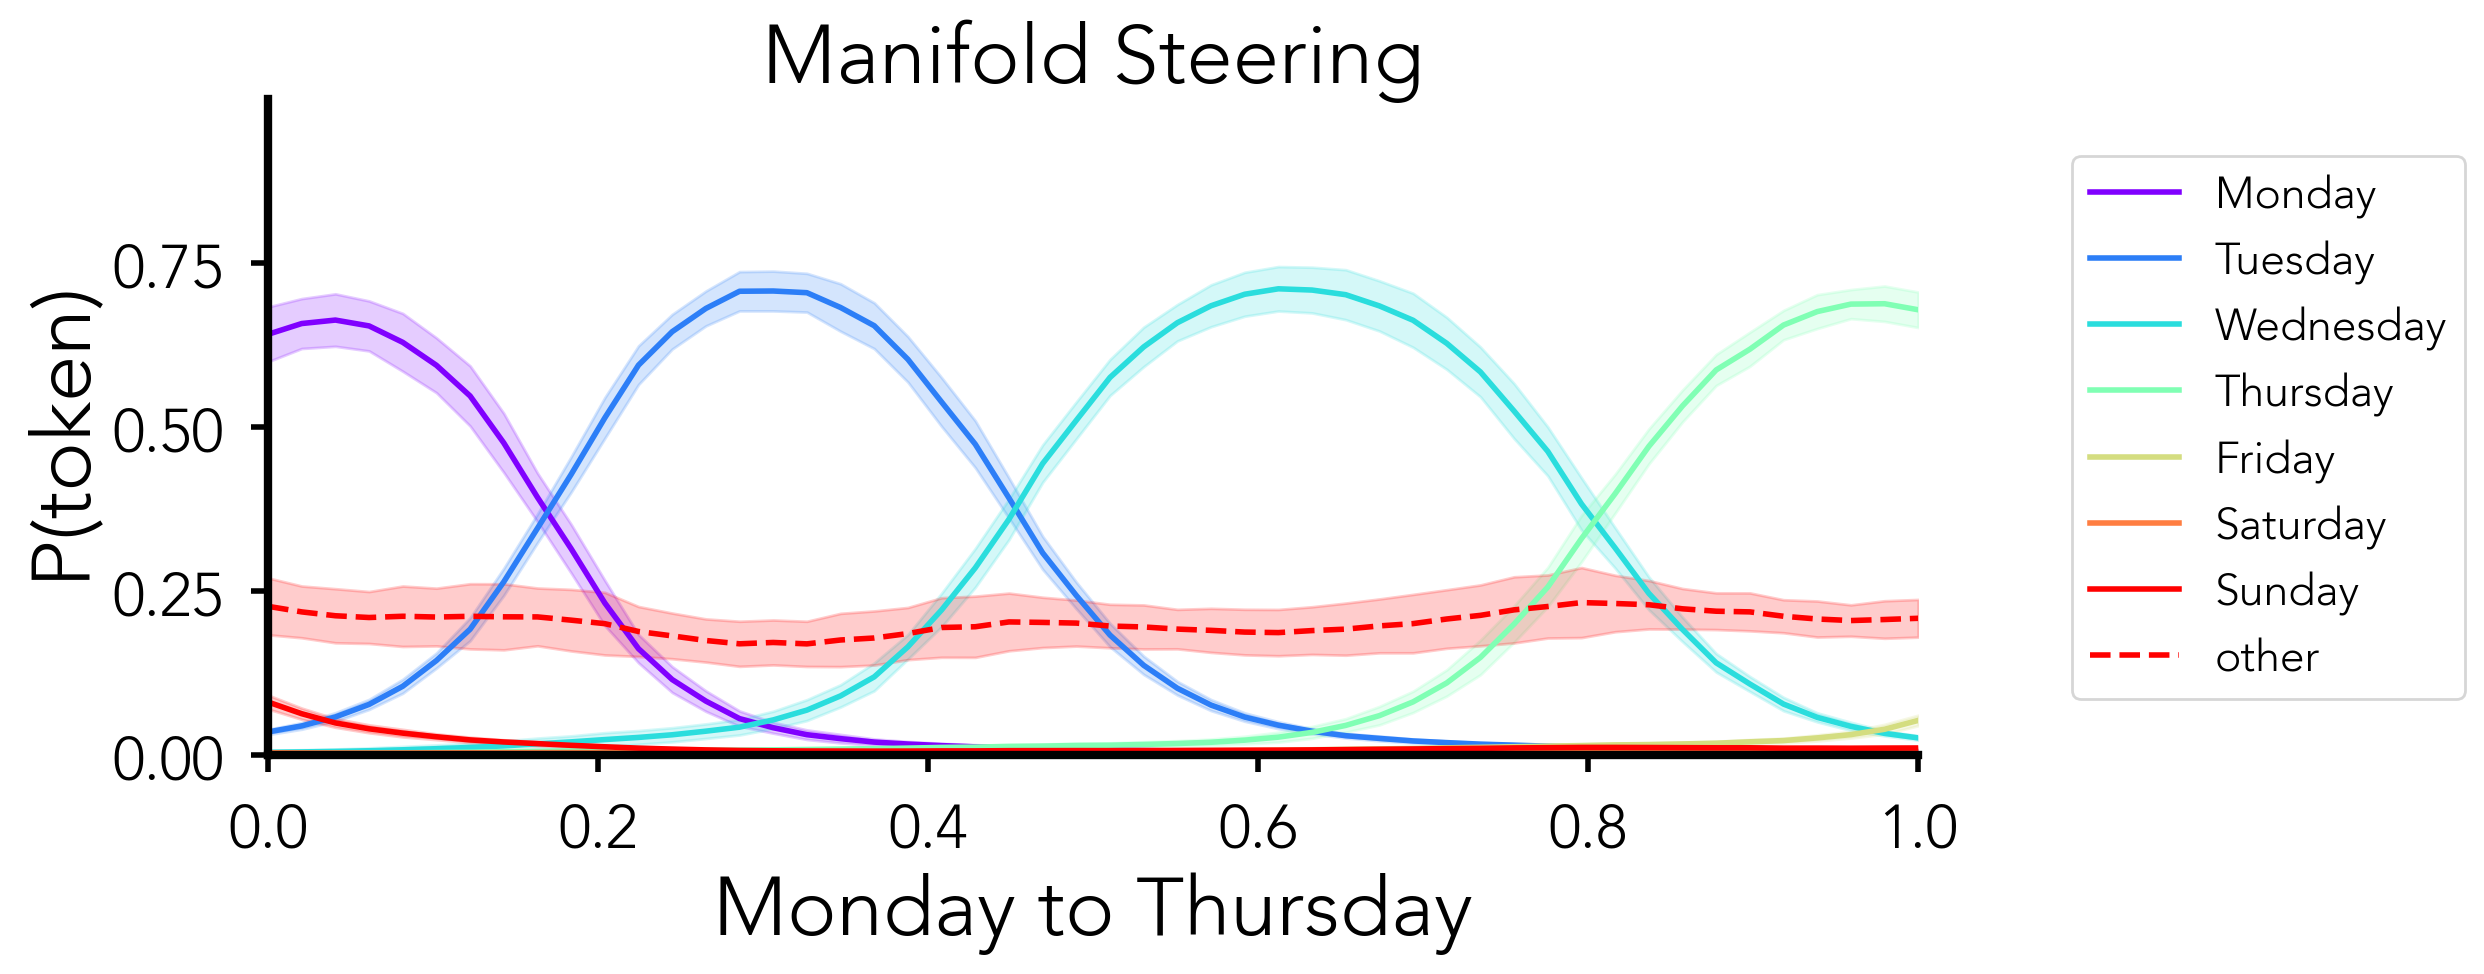

In [36]:
# Geodesic path: output probability landscape stepping along the manifold
geo_img = os.path.join(ps_out_dir, 'vis', 'paths', 'geometric', 'pair_Monday_Thursday.png')
display(Image(filename=geo_img))

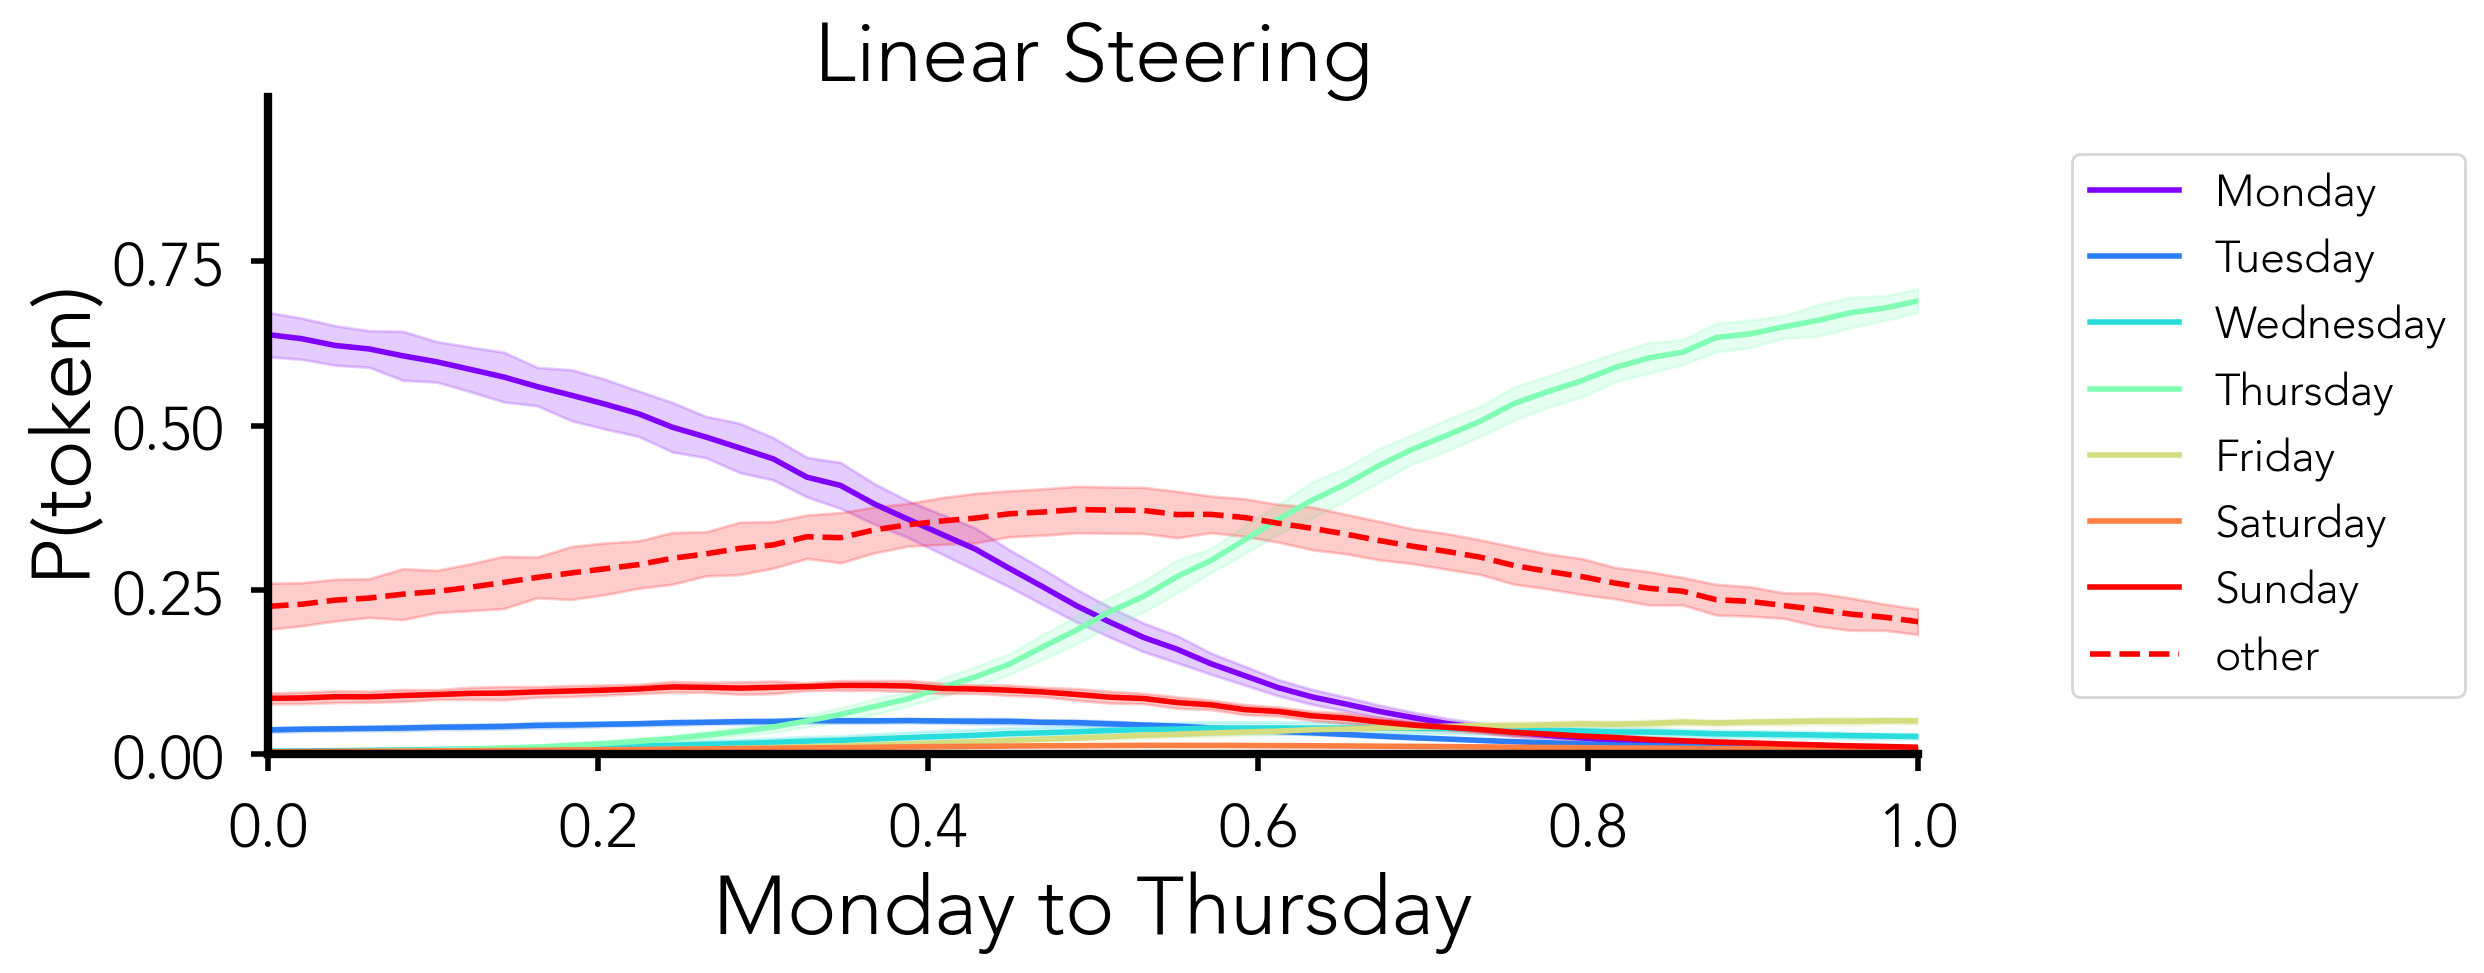

In [37]:
# Linear path: output probability landscape stepping through raw PCA space
lin_img = os.path.join(ps_out_dir, 'vis', 'paths', 'linear', 'pair_Monday_Thursday.png')
display(Image(filename=lin_img))